In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [3]:
()

()

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabhar/zomato-restaurants-in-india")

print("Path to dataset files:", path)

100%|██████████| 17.3M/17.3M [00:00<00:00, 57.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rabhar/zomato-restaurants-in-india/versions/1


In [5]:
import os
print(os.listdir(path))

['zomato_restaurants_in_India.csv']


In [6]:
df = pd.read_csv(os.path.join(path, "zomato_restaurants_in_India.csv"))

In [7]:
df.head(3)

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1


In [8]:
df.shape

(211944, 26)

### **Data Cleaning**

In [9]:
print(f"Number of Columns: {df.shape[1]}")
print(f"Number of Rows: {df.shape[0]}")

Number of Columns: 26
Number of Rows: 211944


In [10]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [11]:
# to check redundant data
df['res_id'].nunique()

55568

In [12]:
# Drop duplicates
df.drop_duplicates(['res_id'], keep='first', inplace=True)

In [13]:
df.shape

(55568, 26)

In [14]:
print(f"Number of Columns: {df.shape[1]}")
print(f"Number of Rows: {df.shape[0]}")

Number of Columns: 26
Number of Rows: 55568


In [15]:
df.sample()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
40245,68767,The Kandyan,['Casual Dining'],https://www.zomato.com/chennai/the-kandyan-bes...,"13, 3rd Avenue, Sai Ram Colony, Besant Nagar,...",Chennai,7,Besant Nagar,13.003969,80.269329,...,1,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.2,Very Good,465,474,0.0,1,-1


In [16]:
df.set_index('res_id', inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55568 entries, 3400299 to 3201138
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  55568 non-null  object 
 1   establishment         55568 non-null  object 
 2   url                   55568 non-null  object 
 3   address               55550 non-null  object 
 4   city                  55568 non-null  object 
 5   city_id               55568 non-null  int64  
 6   locality              55568 non-null  object 
 7   latitude              55568 non-null  float64
 8   longitude             55568 non-null  float64
 9   zipcode               10945 non-null  object 
 10  country_id            55568 non-null  int64  
 11  locality_verbose      55568 non-null  object 
 12  cuisines              55098 non-null  object 
 13  timings               54565 non-null  object 
 14  average_cost_for_two  55568 non-null  int64  
 15  price_range     

In [18]:
df.isna().sum()

,0
name,0
establishment,0
url,0
address,18
city,0
city_id,0
locality,0
latitude,0
longitude,0
zipcode,44623


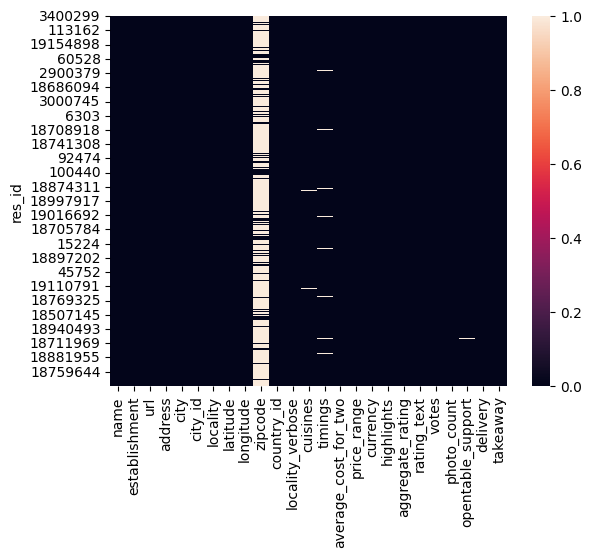

In [19]:
# Check in heat map
sns.heatmap(df.isna())
plt.show()

In [20]:
# Showing in Percentage
(df.isnull().sum()/len(df) * 100).round(2)

,0
name,0.00
establishment,0.00
url,0.00
address,0.03
city,0.00
city_id,0.00
locality,0.00
latitude,0.00
longitude,0.00
zipcode,80.30


## **Statistical Analysis**

In [21]:
# Zip Code:
df.describe().round(2)

,city_id,latitude,longitude,country_id,average_cost_for_two,price_range,aggregate_rating,votes,photo_count,opentable_support,delivery,takeaway
count,55568.00,55568.00,55568.00,55568.0,55568.00,55568.00,55568.00,55568.00,55568.00,55556.0,55568.00,55568.0
mean,3409.50,21.45,76.50,1.0,528.21,1.71,2.96,223.33,160.97,0.0,-0.35,-1.0
std,5174.94,42.90,10.98,0.0,595.03,0.88,1.46,618.22,586.98,0.0,0.93,0.0
min,1.00,0.00,0.00,1.0,0.00,1.00,0.00,-18.00,0.00,0.0,-1.00,-1.0
25%,8.00,16.52,74.65,1.0,200.00,1.00,2.90,6.00,1.00,0.0,-1.00,-1.0
50%,26.00,22.47,77.11,1.0,350.00,1.00,3.50,35.00,10.00,0.0,-1.00,-1.0
75%,11294.00,26.75,79.83,1.0,600.00,2.00,3.90,175.00,69.00,0.0,1.00,-1.0
max,11354.00,10000.00,91.83,1.0,30000.00,4.00,4.90,42539.00,17702.00,0.0,1.00,-1.0


In [22]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [23]:
df['establishment'].unique()

array(["['Quick Bites']", "['Casual Dining']", "['Bakery']", "['Café']",
       "['Dhaba']", "['Bhojanalya']", "['Bar']", "['Sweet Shop']",
       "['Fine Dining']", "['Food Truck']", "['Dessert Parlour']",
       "['Lounge']", "['Pub']", "['Beverage Shop']", "['Kiosk']",
       "['Paan Shop']", "['Confectionery']", '[]', "['Shack']",
       "['Club']", "['Food Court']", "['Mess']", "['Butcher Shop']",
       "['Microbrewery']", "['Cocktail Bar']", "['Pop up']",
       "['Irani Cafe']"], dtype=object)

In [24]:
df['establishment'].nunique()

27

In [25]:
for i in df['establishment'].unique():
    print(i)

['Quick Bites']
['Casual Dining']
['Bakery']
['Café']
['Dhaba']
['Bhojanalya']
['Bar']
['Sweet Shop']
['Fine Dining']
['Food Truck']
['Dessert Parlour']
['Lounge']
['Pub']
['Beverage Shop']
['Kiosk']
['Paan Shop']
['Confectionery']
[]
['Shack']
['Club']
['Food Court']
['Mess']
['Butcher Shop']
['Microbrewery']
['Cocktail Bar']
['Pop up']
['Irani Cafe']


In [26]:
# Remove [''] from establishment columns
df['establishment'] = df['establishment'].apply(lambda x:x[2:-2])

In [27]:
# Replace [] to N/A
df['establishment'] = df['establishment'].apply(lambda x : np.where(x =="", "N/A", x))

In [28]:
df['establishment'].unique()

array(['Quick Bites', 'Casual Dining', 'Bakery', 'Café', 'Dhaba',
       'Bhojanalya', 'Bar', 'Sweet Shop', 'Fine Dining', 'Food Truck',
       'Dessert Parlour', 'Lounge', 'Pub', 'Beverage Shop', 'Kiosk',
       'Paan Shop', 'Confectionery', 'N/A', 'Shack', 'Club', 'Food Court',
       'Mess', 'Butcher Shop', 'Microbrewery', 'Cocktail Bar', 'Pop up',
       'Irani Cafe'], dtype=object)

In [29]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

##  TO DO  >> Timing, Zip Code, NA

In [30]:
df['zipcode']

,zipcode
res_id,
3400299,NaN
3400005,282001.0
3401013,282010.0
3400290,282002.0
3401744,NaN
...,...
19142822,NaN
18984164,NaN
18019952,NaN


In [31]:
#  Fill zipcode into other
df['zipcode'].fillna('Others', inplace=True)

In [32]:
df['zipcode'].isna().sum()

np.int64(0)

In [33]:
df['timings']

,timings
res_id,
3400299,8:30am – 10:30pm (Mon-Sun)
3400005,"12:30PM to 12Midnight (Mon, Wed, Thu, Fri, Sat..."
3401013,9:30 AM to 11 PM
3400290,8am – 11pm (Mon-Sun)
3401744,11:30 AM to 11:30 PM
...,...
19142822,11 AM to 12 Midnight
18984164,"11:30 AM to 3:30 PM, 7:30 PM to 11 PM"
18019952,"11 AM to 3:30 PM, 7 PM to 10:30 PM"


In [34]:
df['currency'].unique()

array(['Rs.'], dtype=object)

In [35]:
df['establishment'].value_counts()

,count
establishment,
Quick Bites,14032
Casual Dining,12270
Café,4123
Bakery,3741
Dessert Parlour,3675
Sweet Shop,2615
Beverage Shop,2440
N/A,1830
Fine Dining,1535


In [36]:
df['establishment'].replace('N/A', 'Other Establishment' , inplace= True)

In [37]:
df['establishment'].unique()

array(['Quick Bites', 'Casual Dining', 'Bakery', 'Café', 'Dhaba',
       'Bhojanalya', 'Bar', 'Sweet Shop', 'Fine Dining', 'Food Truck',
       'Dessert Parlour', 'Lounge', 'Pub', 'Beverage Shop', 'Kiosk',
       'Paan Shop', 'Confectionery', 'Other Establishment', 'Shack',
       'Club', 'Food Court', 'Mess', 'Butcher Shop', 'Microbrewery',
       'Cocktail Bar', 'Pop up', 'Irani Cafe'], dtype=object)

In [38]:
df['establishment'].value_counts()

,count
establishment,
Quick Bites,14032
Casual Dining,12270
Café,4123
Bakery,3741
Dessert Parlour,3675
Sweet Shop,2615
Beverage Shop,2440
Other Establishment,1830
Fine Dining,1535


In [39]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

### **Data Analysis**

In [40]:
df['city'].value_counts().head(20)

,count
city,
Bangalore,2247
Mumbai,2022
Pune,1843
Chennai,1827
New Delhi,1704
Jaipur,1395
Kolkata,1361
Ahmedabad,1247
Goa,1150


In [41]:
df['city'].value_counts().head(20).values

array([2247, 2022, 1843, 1827, 1704, 1395, 1361, 1247, 1150, 1135, 1039,
       1026,  976,  970,  963,  948,  906,  897,  833,  822])

In [42]:
df['city'].value_counts().head(20).index

Index(['Bangalore', 'Mumbai', 'Pune', 'Chennai', 'New Delhi', 'Jaipur',
       'Kolkata', 'Ahmedabad', 'Goa', 'Lucknow', 'Nagpur', 'Indore',
       'Coimbatore', 'Surat', 'Vadodara', 'Ludhiana', 'Bhopal', 'Kochi',
       'Agra', 'Hyderabad'],
      dtype='object', name='city')

In [43]:
 df['city'].value_counts().head(20).reset_index()

,city,count
0,Bangalore,2247
1,Mumbai,2022
2,Pune,1843
3,Chennai,1827
4,New Delhi,1704
5,Jaipur,1395
6,Kolkata,1361
7,Ahmedabad,1247
8,Goa,1150
9,Lucknow,1135


In [44]:
top_20_cities = df['city'].value_counts().head(20).reset_index()
top_20_cities.head(5)

,city,count
0,Bangalore,2247
1,Mumbai,2022
2,Pune,1843
3,Chennai,1827
4,New Delhi,1704


## Visualize

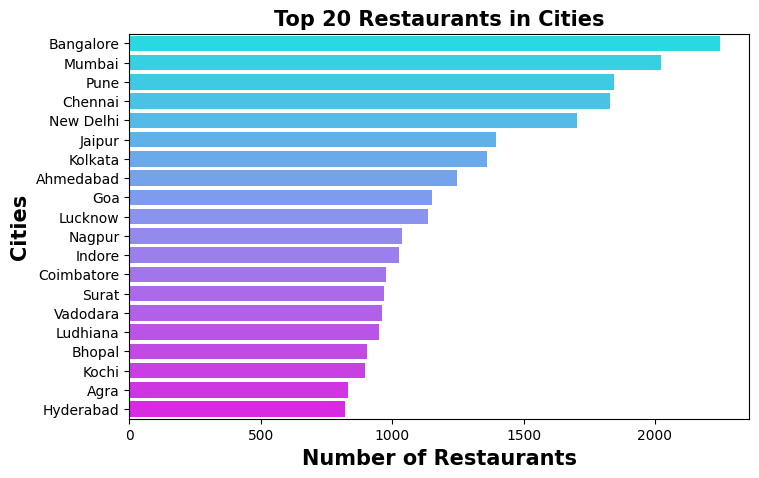

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(y= 'city', x ='count', data=top_20_cities, palette='cool')
plt.title('Top 20 Restaurants in Cities', fontsize = 15, fontweight = 'bold')
plt.xlabel('Number of Restaurants', fontsize = 15, fontweight = 'bold')
plt.ylabel('Cities', fontsize = 15, fontweight = 'bold')
plt.show()

In [46]:
bottom_10_cities = df['city'].value_counts().tail(10).reset_index()
bottom_10_cities.head(5)

,city,count
0,Gandhinagar,96
1,Ghaziabad,90
2,Secunderabad,90
3,Nasik,83
4,Faridabad,79


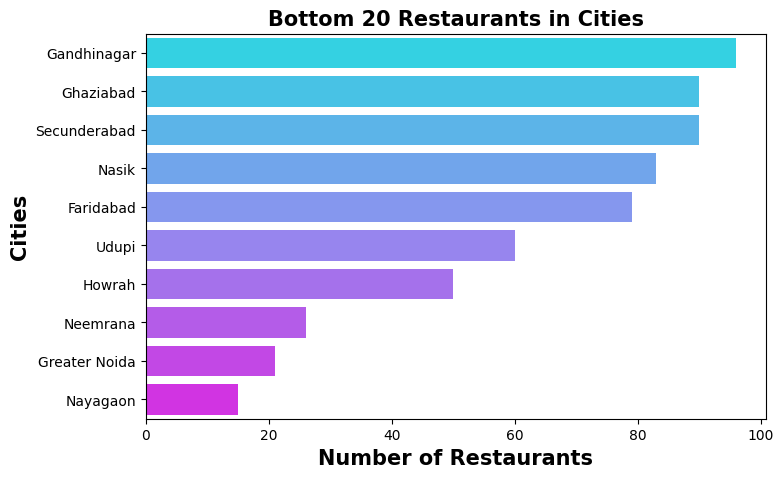

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(y= 'city', x ='count', data=bottom_10_cities, palette='cool')
plt.title('Bottom 20 Restaurants in Cities', fontsize = 15, fontweight = 'bold')
plt.xlabel('Number of Restaurants', fontsize = 15, fontweight = 'bold')
plt.ylabel('Cities', fontsize = 15, fontweight = 'bold')
plt.show()

In [48]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [49]:
top_20_name = df['name'].value_counts().head(20).reset_index()
top_20_name.head(5)

,name,count
0,Domino's Pizza,399
1,Cafe Coffee Day,315
2,KFC,204
3,Baskin Robbins,202
4,Keventers,189


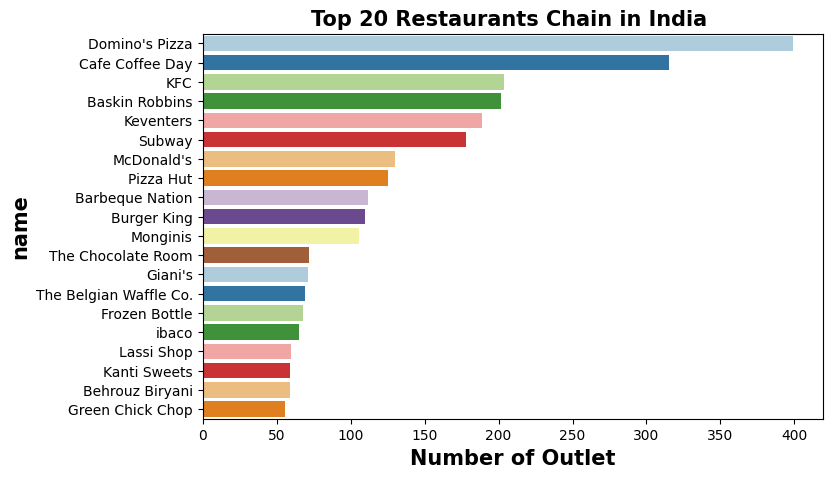

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(y= 'name', x ='count', data=top_20_name, palette='Paired')
plt.title('Top 20 Restaurants Chain in India ', fontsize = 15, fontweight = 'bold')
plt.xlabel('Number of Outlet', fontsize = 15, fontweight = 'bold')
plt.ylabel('name', fontsize = 15, fontweight = 'bold')
plt.show()

In [51]:
bottom_20_name = df['name'].value_counts().tail(20).reset_index()
bottom_20_name.head(5)

,name,count
0,Hotel shelter - The Aroma Kitchen,1
1,Parmanand Sweets,1
2,Real Indian Taste,1
3,Shri Jodhpur Mishtan Bhandar,1
4,Mahalaxmi Restaurant,1


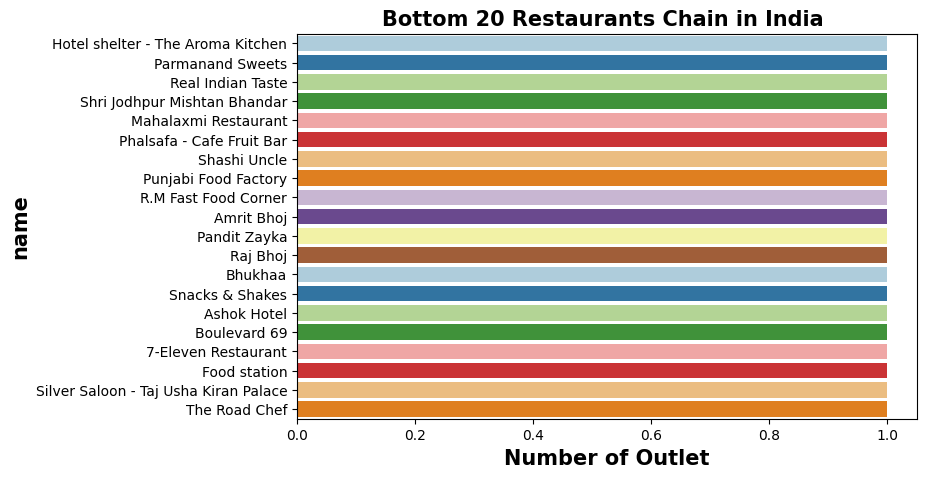

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(y= 'name', x ='count', data=bottom_20_name, palette='Paired')
plt.title('Bottom 20 Restaurants Chain in India ', fontsize = 15, fontweight = 'bold')
plt.xlabel('Number of Outlet', fontsize = 15, fontweight = 'bold')
plt.ylabel('name', fontsize = 15, fontweight = 'bold')
plt.show()

In [53]:
by_establishment = df['establishment'].value_counts().head(10).reset_index()
by_establishment.head(10)

,establishment,count
0,Quick Bites,14032
1,Casual Dining,12270
2,Café,4123
3,Bakery,3741
4,Dessert Parlour,3675
5,Sweet Shop,2615
6,Beverage Shop,2440
7,Other Establishment,1830
8,Fine Dining,1535
9,Food Court,1494


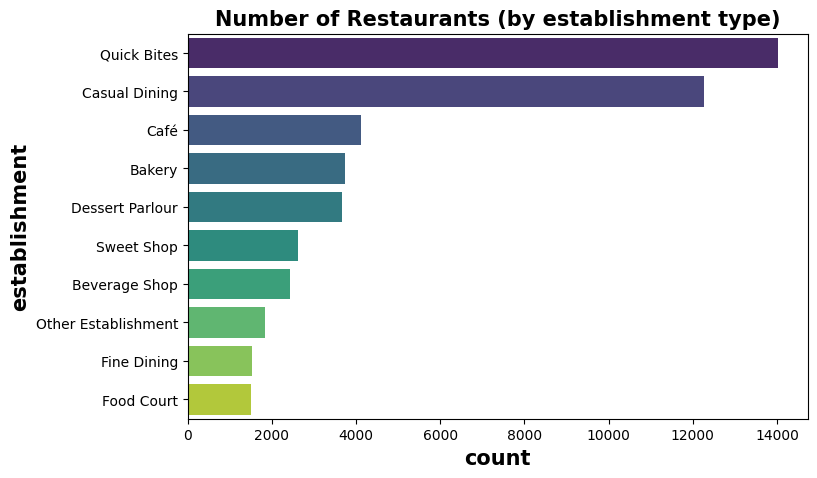

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(y= 'establishment', x ='count', data=by_establishment, palette='viridis')
plt.title('Number of Restaurants (by establishment type)', fontsize = 15, fontweight = 'bold')
plt.xlabel('count', fontsize = 15, fontweight = 'bold')
plt.ylabel('establishment', fontsize = 15, fontweight = 'bold')
plt.show()

In [55]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [56]:
by_cuisines = df['cuisines'].value_counts().head(10).reset_index()
by_cuisines.head(10)

,cuisines,count
0,North Indian,4295
1,Fast Food,2025
2,"North Indian, Chinese",1636
3,Bakery,1585
4,South Indian,1489
5,Street Food,1187
6,Cafe,1098
7,Mithai,1020
8,Desserts,922
9,"Bakery, Desserts",836


In [57]:
()

()

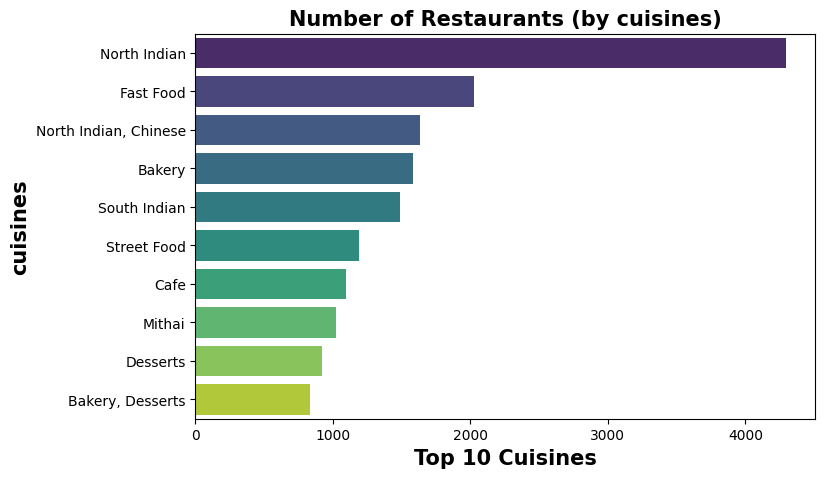

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(y= 'cuisines' , x ='count', data = by_cuisines, palette='viridis')
plt.title('Number of Restaurants (by cuisines)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Top 10 Cuisines', fontsize = 15, fontweight = 'bold')
plt.ylabel('cuisines', fontsize = 15, fontweight = 'bold')
plt.show()

In [59]:
df['price_range'].unique()

array([2, 1, 3, 4])

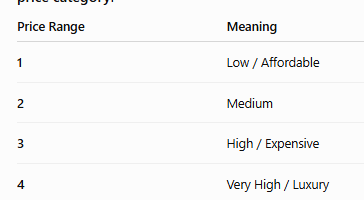

In [63]:
from IPython.display import Image, display

display(Image('/content/Screenshot 2026-09-04 174102.png'))

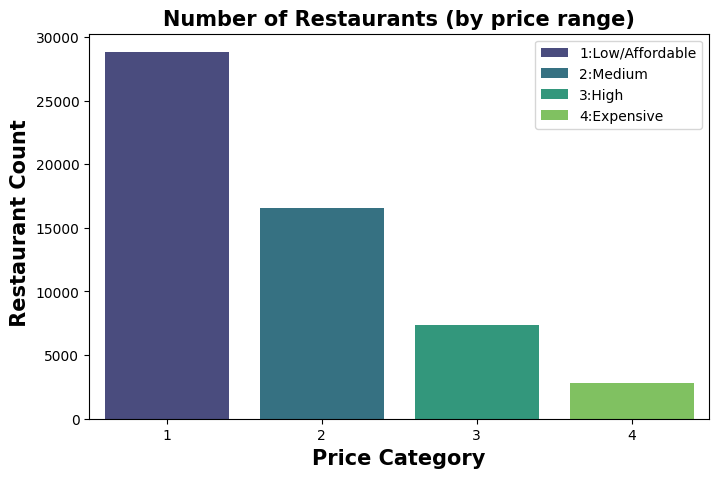

In [66]:
plt.figure(figsize=(8,5))
sns.countplot(x='price_range', data=df, palette='viridis')
plt.title('Number of Restaurants (by price range)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Price Category', fontsize = 15, fontweight = 'bold')
plt.ylabel(' Restaurant Count', fontsize = 15, fontweight = 'bold')
plt.legend(['1:Low/Affordable', '2:Medium', '3:High','4:Expensive'])
plt.show()

In [70]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [71]:
df[df[ 'price_range']==1]['average_cost_for_two'].max()

450

In [74]:
p1_max = df[df[ 'price_range']==1]['average_cost_for_two'].max()
p2_max = df[df[ 'price_range']==2]['average_cost_for_two'].max()
p3_max= df[df[ 'price_range']==3]['average_cost_for_two'].max()
p4_max = df[df[ 'price_range']==4]['average_cost_for_two'].max()

p1_min = df[df[ 'price_range']==1]['average_cost_for_two'].min()
p2_min = df[df[ 'price_range']==2]['average_cost_for_two'].min()
p3_min= df[df[ 'price_range']==3]['average_cost_for_two'].min()
p4_min = df[df[ 'price_range']==4]['average_cost_for_two'].min()

print(p1_max, p2_max, p3_max, p4_max)
print(p1_min, p2_min, p3_min, p4_min)

450 999 1900 30000
0 250 500 1000


In [69]:
# Minimum price for category assume
price = pd.DataFrame({'Price category':[1,2,3,4],
                      'Price Range':['50-450','250-999','500-1900','1000-30000']}, index=range(1,5))
price

,Price category,Price Range
1,1,50-450
2,2,250-999
3,3,500-1900
4,4,1000-30000


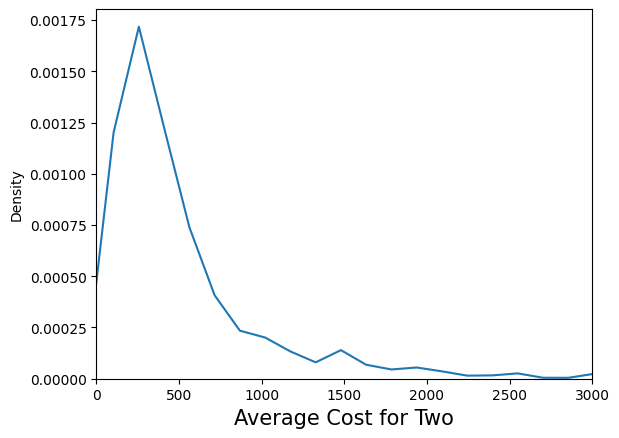

In [77]:
sns.kdeplot(df['average_cost_for_two'])
plt.xlim(0,3000)
plt.xlabel('Average Cost for Two', fontsize = 15)
plt.show()

In [81]:
luxury = df.groupby(['name', 'establishment', 'city'])['average_cost_for_two'].max().sort_values(ascending=False).head(10)
luxury

,,,average_cost_for_two
name,establishment,city,
Ocean - The Private Dining Room - Sahara Star,Fine Dining,Mumbai,30000
Bhairo,Fine Dining,Udaipur,15000
Gol Bungalow - Taj Falaknuma Palace,Fine Dining,Hyderabad,15000
Fly Dining,Fine Dining,Bangalore,14000
Trophy Bar- Umaid Bhawan Palace,Bar,Jodhpur,12000
Risala- Umaid Bhawan Palace,Fine Dining,Jodhpur,12000
Pillars - Umaid Bhawan Palace,Fine Dining,Jodhpur,12000
Wasabi By Morimoto - The Taj Mahal Palace,Fine Dining,Mumbai,10000
Orient Express - Taj Palace,Fine Dining,New Delhi,8000


In [82]:
df.columns

Index(['name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

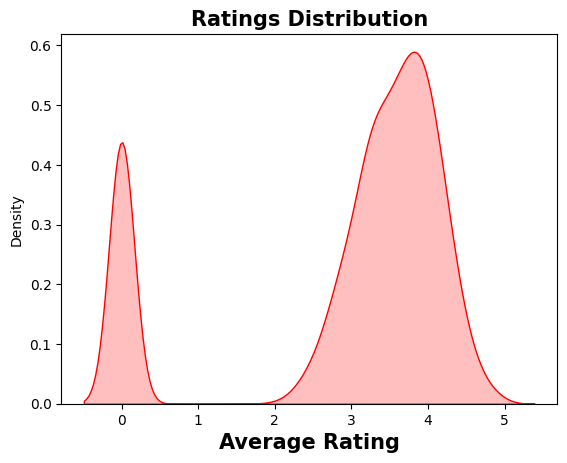

In [86]:
sns.kdeplot(df['aggregate_rating'], fill=True, color='r')
plt.title('Ratings Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Average Rating', fontsize=15, fontweight='bold')
plt.show()

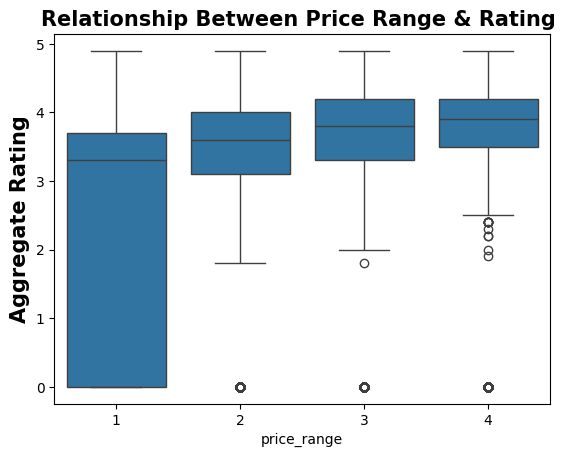

In [90]:
sns.boxplot(x ='price_range', y = 'aggregate_rating' , data = df)
plt.title("Relationship Between Price Range & Rating ", fontsize= 15, fontweight= 'bold')
plt.ylabel('Aggregate Rating', fontsize= 15, fontweight= 'bold')
plt.show()

In [92]:
def check(input_list):
  if 'Delivery' in input_list:
    return 'Delivery Available'
  elif 'Takeaway Available' in input_list:
    return 'Takeaway Available'
  else:
    return 'No Return Delivery Avialble'

In [96]:
  ff = df['highlights'].apply(check).value_counts().reset_index()
  ff

,highlights,count
0,Takeaway Available,24769
1,Delivery Available,23907
2,No Return Delivery Avialble,6892


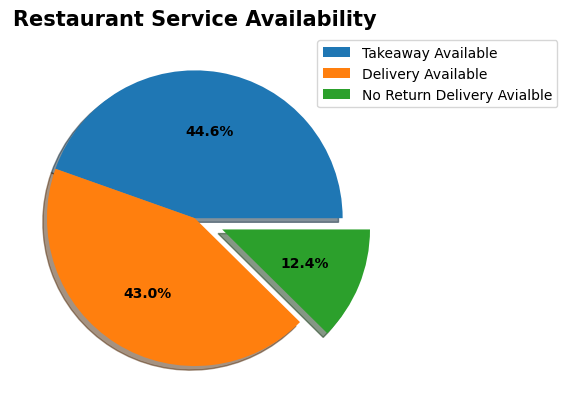

In [102]:
ex = [0.0, 0.0, 0.2]

plt.pie(ff['count'],
        explode = ex,
        autopct = '%1.1f%%',
        shadow= True,
        radius = 1,
        textprops = {"fontsize": 10, "fontweight": 'bold'})
plt.title("Restaurant Service Availability", fontsize = 15, fontweight = 'bold')
plt.legend(labels= ff['highlights'], loc = 'upper right', bbox_to_anchor = (1.5,1))
plt.show()

In [104]:
from wordcloud import WordCloud

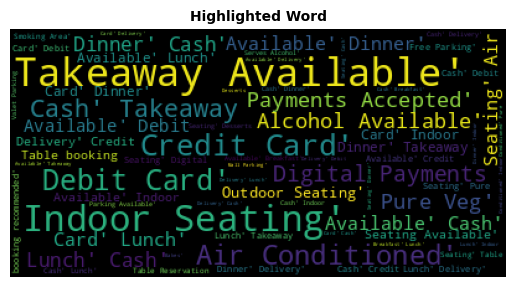

In [106]:
text = ' '.join(df['highlights'])

# Generate Wordcloud
wordcloud = WordCloud().generate(text)

plt.imshow(wordcloud)
plt.title('Highlighted Word',fontsize = 10, fontweight = 'bold')
plt.axis('off')
plt.show()